# K-NN

- find k nearest neighbors
- take they classes
- majority vote (always pick k = odd) 
    - In a way that this is not divisible by number of classes.
    - assume 5 classes and picking odd k as 5, all classes get 3-3 records, now we are stuck again.
    

### Failure cases
- distant neighbour
- falls in outliers etc


### Distances types (to find neighbors)
- euclidean distance <- L2 norm
- manhattan distance <- L1 norm
- hamming distance <- number of dimensions where vector values are different
- cosine distance  = 1 - cosine similarity (Ex: cos(theta))


L1 norm of a vector: Summation of all absolute components 

...

Lp norm of a vector: (Summation of absolute(x1i - x2i) to power p) to power (1/p) [ Also called minkowski distance]


Dn = D_train + D_test

## How to split
- randomly (Example: 70% in train and 30% in test)
    - Train your model using D_train
    - Test your model in D_test
- time based splitting (sort based on time and then do splitting)

## Time and Space Complexity
- Time : O (n x d)
- Space : O ((n + k) x d)
- At evaluation/test time: all 
 

# OverFitting and Underfitting

- Underfitting: too big K
- OverFitting: too small k that outliers can impact

# Steps
- for multiple Ks, train using D_train and predict accuracy using D_test


## Cross validation
Dn = 
    D_train (for NN) + 
    D_cv (for K) + 
    D_test (unseen data, used to evaluate)

### Problem with this
using too less data for training.

### K-fold cross-validation
- break in two (d_train, d_test)
- break d_train into parts (example 4 parts: d1, d2, d3, d4)
- pick any 3 for NN and 1 for k and keep switching for all combinations for many value of Ks (ex: k=1, then k=2, then k = 3, ...)
- for every k, can take avg accuracy for all combinations

### Note
- time complexity increases k times for k-fold.
- column standardization is needed because distance can be impacted by scale.

# Errors

### Train error
- while computing for k using d_train is train error  

### Validation error
- while doing cv (cross validation)

### Over fitting
- when your train error is small and cv error is large => overfit

### Under fitting
- when your train error is large and cv error is large => underfit

If you see, then need to pick lowest cv error for sure.



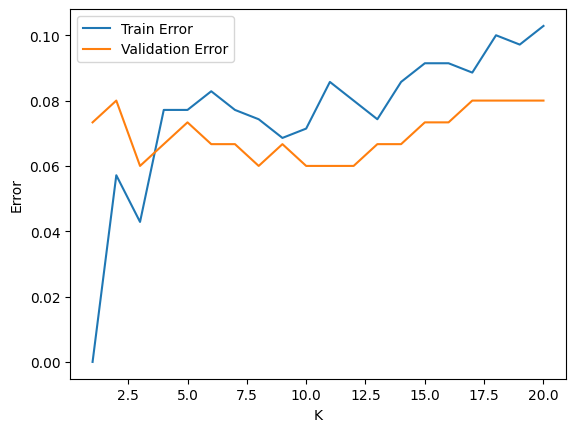

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# synthetic dataset
X, y = make_classification(n_samples=500, n_features=5, random_state=42)

# split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

k_values = range(1, 21)
train_errors = []
val_errors = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    train_error = 1 - model.score(X_train, y_train)
    val_error = 1 - model.score(X_val, y_val)
    
    train_errors.append(train_error)
    val_errors.append(val_error)

# plot
plt.plot(k_values, train_errors, label="Train Error")
plt.plot(k_values, val_errors, label="Validation Error")
plt.xlabel("K")
plt.ylabel("Error")
plt.legend()
plt.show()



KNN can be used for regression as well, find neighbours and take mean or somethjing similar.

# Weighted K-NN
- rather than pickking majority, give importance to those which are closer than those which are farther.
- example: weight = (1 / distance) (or some function of inverse of distance)


# Kd tree
Just like quad tree with multi dimensions

### Limitations
- when d is not small, near edge points need to explore 2^d 


# Hashing & Locality Sensitive hashing
- just like geo hashing.

### Locality sensitive hashing for cosine similarity
- randomized algo
- not always right    
- generate multiple hyper planes and slice space and assign space based on direction from planes (cosine distance) and group the ones in same area.
- key like (+1, +1, +1, -1, -1, +1)

#### Limitations
- neighbours can be missed as plane goes from between
- hence generate multitple times
- keep multiple hash tables

#### Time Complexity
O(m x d x L)
m : number of hyperplanes (right choice is very important because there is trade off of having large vs small number)
d : dimensions
L : number of hash tables 


### Locality sensitive hashing for euclidean distance
- same but not there is no cosine distance but euclidean distance from hyper planes


- KNN can do multi class classification as well along with predicting their probability
- If similarity matrix are given, then it doesn't need vector and other stuff, as it only cares about distance and k nearest neighbors.

- we can train model to classify distribution between D_test and D_train, whenever we see there is very less overlap, meaning features are changing and d_test is very different, we might need to retrain model.

# Pointers
- should not be used in low latency system
- not good for high dimensional data (ex: <= 10)
- find right distance measure (as per data - use domain knowledge)